/kaggle/input/datasets/adeelbytes/malmem/final_malmem.csv
Training Random Forest... Please wait.

--- Model Performance ---
Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1956
           1       1.00      1.00      1.00      1906

    accuracy                           1.00      3862
   macro avg       1.00      1.00      1.00      3862
weighted avg       1.00      1.00      1.00      3862



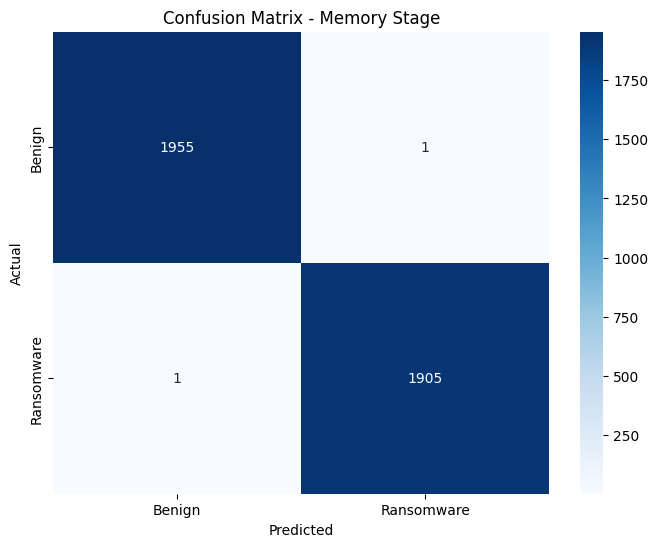

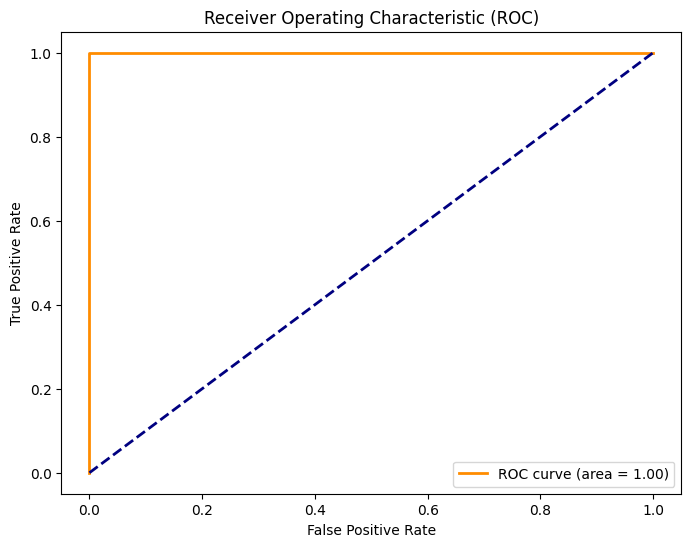


✅ Success! Saved 'rf_memory_model.joblib' and 'memory_scaler.joblib'


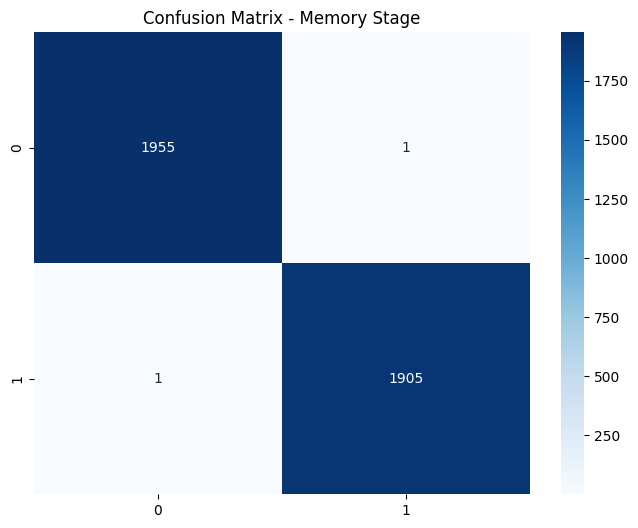

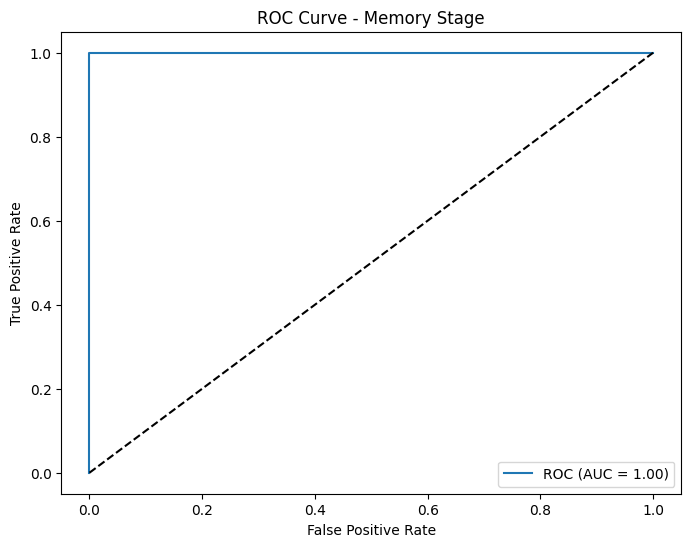

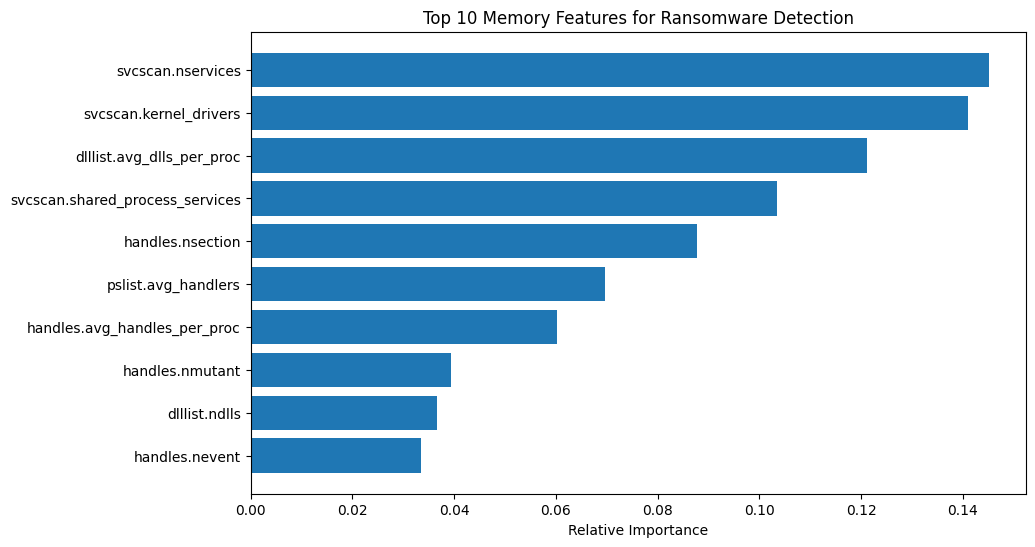

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score

# 1. LOAD DATASET (Kaggle Specific Path)
# Kaggle datasets are in /kaggle/input/. Use this to find your exact path:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# REPLACE THE PATH BELOW with the one printed above
path = '/kaggle/input/datasets/adeelbytes/malmem/final_malmem.csv' 
df = pd.read_csv(path)

# 2. Preprocessing
# Remove columns that aren't features (IDs or labels)
# Assuming 'Class' is 'Benign/Malware' and 'Category' is 'Ransomware'
X = df.drop(['Class', 'Category'], axis=1) 
y = df['Class'].apply(lambda x: 1 if x != 'Benign' else 0)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling (CRITICAL for the pipeline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize & Train Random Forest
print("Training Random Forest... Please wait.")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# 6. Predictions
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# --- EVALUATION SECTION ---

print("\n--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Confusion Matrix Visualization
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Ransomware'], yticklabels=['Benign', 'Ransomware'])
plt.title('Confusion Matrix - Memory Stage')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 8. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# --- EXPORT FOR PIPELINE ---

# Save the model
joblib.dump(rf_model, 'rf_memory_model.joblib')
# Save the scaler (You MUST use this in your Streamlit app before predicting)
joblib.dump(scaler, 'memory_scaler.joblib')

print("\n✅ Success! Saved 'rf_memory_model.joblib' and 'memory_scaler.joblib'")


# ... [Assuming the previous training code was run] ...

# 1. Save Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Memory Stage')
plt.savefig('confusion_matrix.png', dpi=300) # SAVES TO DISK
plt.show()

# 2. Save ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Memory Stage')
plt.legend()
plt.savefig('roc_curve.png', dpi=300) # SAVES TO DISK
plt.show()

# 3. Save Feature Importance (NEW - Highly recommended for FYP)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features
plt.figure(figsize=(10,6))
plt.title('Top 10 Memory Features for Ransomware Detection')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.savefig('feature_importance.png', dpi=300) # SAVES TO DISK
plt.show()